# Feature Extractor

In [1]:
import cv2
import numpy as np
import os
import sys
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [110]:
image_fp = os.path.expanduser("~/data/Images/24-10-05 Saturn-480p.jpg")
# image_fp = os.path.expanduser("~/data/Images/train-window-small.jpg")

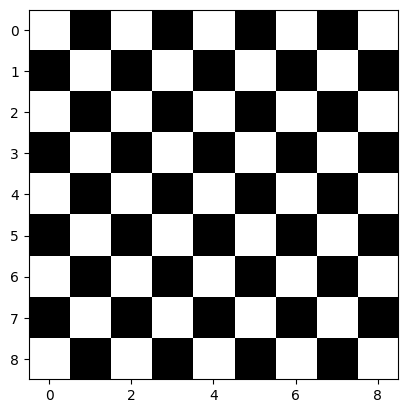

In [111]:
def display_image(im: cv2.Mat, title: str = None, show_ticks: bool = True) -> None:
    if im is None:
        print("Error: Image is None")
        return

    img_rgb = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

    plt.imshow(img_rgb)
    if title is not None:
        plt.title(title)
    if not show_ticks:
        plt.xticks([])
        plt.yticks([])
    plt.show()


def generate_checker(size: int) -> np.ndarray:
    checkerboard = np.zeros((size, size), dtype=np.uint8)
    for y in range(size):
        for x in range(size):
            if y % 2 == 0:
                if x % 2 == 0:
                    checkerboard[y, x] = 255
            else:
                if x % 2 == 1:
                    checkerboard[y, x] = 255
    return checkerboard

display_image(generate_checker(9))

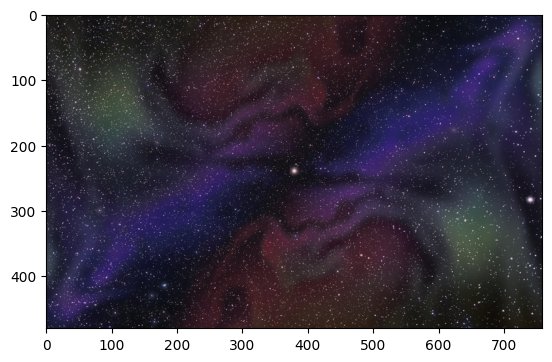

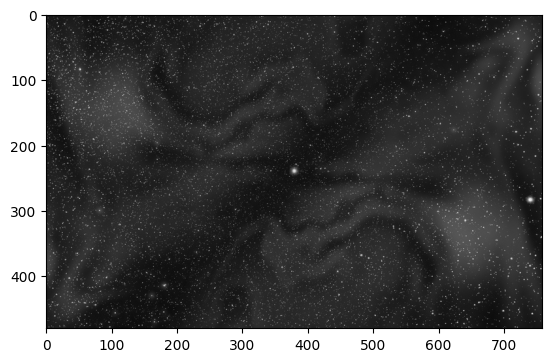

In [112]:
image = cv2.imread(image_fp)
image_bw = cv2.imread(image_fp, cv2.IMREAD_GRAYSCALE)
display_image(image)
display_image(image_bw)

In [113]:
def square_window_mask(w: int) -> np.ndarray:
    mask = np.ones((w, w), dtype=np.uint8)
    return mask

def set_mat_to_zero(im: cv2.Mat) -> None:
    im[:, :] = 0

def tl_br(o: tuple[int, int], w: int, d_yx: tuple[int, int]) -> tuple[tuple[int, int], tuple[int, int]]:
    return (o[0] - w//2 + d_yx[0], o[1] - w//2 + d_yx[1]), (o[0] + w//2 + d_yx[0] + 1, o[1] + w//2 + d_yx[1] + 1)

def compute_corner_val(im: cv2.Mat, p_yx: tuple[int, int], w: int = 3, diff_metric: str = "L2", window_mask: callable = square_window_mask) -> float:
    if diff_metric == "L2":
        diff_func = lambda v1, v2: (v1-v2)**2
    elif diff_metric == "L1":
        diff_func = lambda v1, v2: abs(v1-v2)
    else:
        raise ValueError(f"{diff_metric} is not a valid metric. Use `L1` or `L2`.")
    
    working_patch_size = w + (w//2) * 2

    ref_p1, ref_p2 = tl_br((p_yx[0], p_yx[1]), working_patch_size, (0, 0))
    full_reference_patch = im[ref_p1[0]:ref_p2[0], ref_p1[1]:ref_p2[1]]

    wrk_patch_tl, wrk_patch_bl = tl_br((working_patch_size//2, working_patch_size//2), w, (0, 0))
    wrk_patch = full_reference_patch[wrk_patch_tl[0]:wrk_patch_bl[0], wrk_patch_tl[1]:wrk_patch_bl[1]]
    wrk_patch = wrk_patch.astype(np.float32)

    mask = window_mask(w)

    dists = []
    for w_cy in range(-(w//2), w//2 + 1):
        for w_cx in range(-(w//2), w//2 + 1):
            if w_cy == 0 and w_cx == 0:
                continue
            # get the offset positions
            tl, br = tl_br((working_patch_size//2, working_patch_size//2), w, (w_cy, w_cx))
            shifted_patch = full_reference_patch[tl[0]:br[0], tl[1]:br[1]]
            shifted_patch = shifted_patch.astype(np.float32)

            # calculate distance
            distance = diff_func(shifted_patch, wrk_patch)
            distance *= mask
            dists.append(np.sum(distance))

    return min(dists)


def compute_all_corners(im: cv2.Mat, w: int = 3, diff_metric: str = "L2") -> np.ndarray:
    vals = np.zeros_like(im, dtype=np.float32)
    working_patch_size = w + (w//2) * 2
    tq = tqdm(total=(im.shape[0] - working_patch_size) * (im.shape[1] - working_patch_size), desc="Computing Corners")
    for y in range(working_patch_size//2, im.shape[0] - working_patch_size//2):
        for x in range(working_patch_size//2, im.shape[1] - working_patch_size//2):
            cval = compute_corner_val(im, (y, x), w, diff_metric)
            vals[y, x] = cval
            tq.update(1)
    tq.close()
    return vals

vals = compute_all_corners(image_bw, w=5, diff_metric="L2")

Computing Corners:   0%|          | 0/353250 [00:00<?, ?it/s]

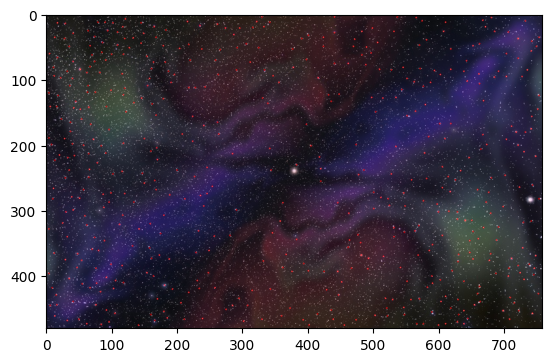

In [114]:
top_k = 1000

def get_best_corners(vals: np.ndarray, top_k: int, min_distance: int = 10) -> list[tuple[int, int]]:
    # 1. Grab a larger pool of the HIGHEST values to allow for NMS filtering
    pool_size = min(top_k * 5, vals.size)
    
    # Use negative indexing in argpartition to get the largest elements
    flat_indices = np.argpartition(vals.flatten(), -pool_size)[-pool_size:]
    
    # 2. Sort the pool descending so we process the absolute best corners first
    flat_indices = flat_indices[np.argsort(vals.flatten()[flat_indices])][::-1]
    coords = [np.unravel_index(idx, vals.shape) for idx in flat_indices]

    # 3. Non-Maximum Suppression
    selected_corners = []
    for r, c in coords:
        # Check squared distance against all currently selected corners
        if all((r - sr)**2 + (c - sc)**2 >= min_distance**2 for sr, sc in selected_corners):
            selected_corners.append((r, c))
            if len(selected_corners) == top_k:
                break
                
    return selected_corners

# plot the corner points on the image
def save_image_with_corners(im: cv2.Mat, corner_points: list[tuple[int, int]], fp: str = None) -> None:
    img_rgb = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    for y, x in corner_points:
        cv2.circle(img_rgb, (x, y), radius=1, color=(255, 0, 0), thickness=0)
    plt.imshow(img_rgb)
    cv2.imwrite(fp, cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))

corner_points = get_best_corners(vals, top_k=top_k, min_distance=10)
save_image_with_corners(image, corner_points, fp="detected_corners.png")